In [1]:
# ── Colab Setup (skip automatically if running locally) ──────────────────────
import sys, os

# Reproducibility pin: check out this exact commit inside the Colab clone so
# scripts/models/*.py and data/splits/*.parquet match the code+data these
# notebook cells were run against — `git clone --branch Model` alone would
# silently pull the branch's latest tip instead. Bump this hash per logged run.
TARGET_COMMIT = 'f9a6169'

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    # transformers provides HuggingFace PatchTST (fully multivariate)
    subprocess.run(['pip', 'install', 'transformers', '-q'], check=True)

    # Clone the repo (git-tracked data/splits/*.parquet come along for free —
    #    no manual upload needed), pinned to TARGET_COMMIT
    REPO_URL = 'https://github.com/WoodyChang21/ECE1508_GenAI.git'
    if not os.path.exists('/content/ECE1508_GenAI'):
        subprocess.run(
            ['git', 'clone', '--branch', 'Model', REPO_URL, '/content/ECE1508_GenAI'],
            check=True,
        )
    subprocess.run(['git', '-C', '/content/ECE1508_GenAI', 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', '/content/ECE1508_GenAI', 'checkout', TARGET_COMMIT], check=True)
    print(f"Checked out /content/ECE1508_GenAI at {TARGET_COMMIT}")
    os.chdir('/content/ECE1508_GenAI/notebooks')

    os.makedirs('/content/ECE1508_GenAI/data/predictions', exist_ok=True)

    missing = [
        f for f in ['train.parquet', 'val.parquet', 'test.parquet']
        if not os.path.exists(f'/content/ECE1508_GenAI/data/splits/{f}')
    ]
    if missing:
        raise FileNotFoundError(
            'Missing data splits after clone: ' + ', '.join(missing)
            + f'. Ensure commit {TARGET_COMMIT} includes data/splits/*.parquet.'
        )
    print('Data splits found from clone — no upload needed.')

    import torch
    if torch.cuda.is_available():
        print(f'\nGPU: {torch.cuda.get_device_name(0)}')
    else:
        print('\nNo GPU detected. Go to Runtime -> Change runtime type -> T4 GPU.')

print('Setup complete.')


Checked out /content/ECE1508_GenAI at f9a6169
Data splits found from clone — no upload needed.

GPU: NVIDIA A100-SXM4-80GB
Setup complete.


In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import DeepAR
from neuralforecast.losses.pytorch import DistributionLoss, MQLoss

from scripts.models.data_loader import load_nf_dataframe, build_full_df, FUTR_EXOG_COLS
from scripts.models.metrics import compute_all

plt.rcParams['figure.figsize'] = (14, 4)

CANDIDATES = [24, 60, 120, 240]
FREQ = 1   # integer ds — avoids market-hours gap issues

In [4]:
extra = FUTR_EXOG_COLS  # ['is_first_bar']

train_df = load_nf_dataframe('../data/splits/train.parquet', extra_cols=extra)
val_df   = load_nf_dataframe('../data/splits/val.parquet',   extra_cols=extra)
test_df  = load_nf_dataframe('../data/splits/test.parquet',  extra_cols=extra)

# Contiguous ds sequences for cross_validation
trainval_df = build_full_df([train_df, val_df])
full_df     = build_full_df([train_df, val_df, test_df])

print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")
print(f"trainval: {len(trainval_df):,}  full: {len(full_df):,}")
print(f"futr_exog columns: {FUTR_EXOG_COLS}")
print(full_df.head(3))

train: 21,028  val: 1,744  test: 2,469
trainval: 22,772  full: 25,241
futr_exog columns: ['is_first_bar', 'is_last_bar', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_monday', 'is_friday', 'month_sin', 'month_cos', 'is_month_end', 'is_month_start', 'is_quarter_end']
  unique_id  ds         y  is_first_bar  is_last_bar  hour_sin  hour_cos  \
0       SPY   0 -0.002645         False        False  0.935016 -0.354605   
1       SPY   1  0.001623         False        False  0.239316 -0.970942   
2       SPY   2  0.000473         False         True -0.464723  0.885456   

    dow_sin   dow_cos  is_monday  is_friday  month_sin  month_cos  \
0  0.951057  0.309017      False      False        0.0        1.0   
1  0.951057  0.309017      False      False        0.0        1.0   
2  0.951057  0.309017      False      False        0.0        1.0   

   is_month_end  is_month_start  is_quarter_end  
0         False           False           False  
1         False           False           False

In [5]:
val_maes = {}

for input_size in CANDIDATES:
    model = DeepAR(
        h=1,
        input_size=input_size,
        lstm_hidden_size=128,
        lstm_n_layers=2,
        lstm_dropout=0.1,
        trajectory_samples=100,          # fewer samples for speed during tuning
        loss=DistributionLoss(distribution='StudentT', level=[80, 90]),
        valid_loss=MQLoss(level=[80, 90]),
        futr_exog_list=FUTR_EXOG_COLS,
        max_steps=500,
        early_stop_patience_steps=-1,    # disable early stopping; cross_validation has no val split
        scaler_type='standard',
    )
    nf = NeuralForecast(models=[model], freq=FREQ)
    # cross_validation treats last test_size rows of trainval_df as the "test" (= val here)
    # n_windows=None is required when test_size is provided (NeuralForecast 1.7.7 API)
    cv = nf.cross_validation(
        df=trainval_df,
        n_windows=None,
        test_size=len(val_df),
        step_size=1,
        refit=False,
    )
    val_mae = float(np.mean(np.abs(cv['y'].values - cv['DeepAR'].values)))
    val_maes[input_size] = val_mae
    print(f"  input_size={input_size:3d}  val MAE={val_mae:.6f}")

best_input_size = min(val_maes, key=val_maes.get)
print(f"\nBest input_size: {best_input_size}  (val MAE={val_maes[best_input_size]:.6f})")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | loss                | DistributionLoss | 5      | train
1 | valid_loss          | MQLoss           | 5      | train
2

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

  input_size=240  val MAE=0.002154

Best input_size: 120  (val MAE=0.002150)


In [6]:
# Train on train+val (full_df minus last test_size rows), predict across test
final_model = DeepAR(
    h=1,
    input_size=best_input_size,
    lstm_hidden_size=128,
    lstm_n_layers=2,
    lstm_dropout=0.1,
    trajectory_samples=200,
    loss=DistributionLoss(distribution='StudentT', level=[80, 90]),
    valid_loss=MQLoss(level=[80, 90]),
    futr_exog_list=FUTR_EXOG_COLS,
    max_steps=1000,
    early_stop_patience_steps=-1,    # disable early stopping; cross_validation has no val split
    scaler_type='standard',
)
nf_final = NeuralForecast(models=[final_model], freq=FREQ)

# n_windows=None is required when test_size is provided (NeuralForecast 1.7.7 API)
cv_test = nf_final.cross_validation(
    df=full_df,
    n_windows=None,
    test_size=len(test_df),
    step_size=1,
    refit=False,
)

print(f"Test predictions: {len(cv_test):,} rows")
print(f"Columns: {list(cv_test.columns)}")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | loss                | DistributionLoss | 5      | train
1 | valid_loss          | MQLoss           | 5      | train
2 | hist_cat_embeddings | ModuleList       | 0      | train
3 | futr_cat_embeddings | ModuleList       | 0      | train
4 | stat_cat_embeddings | ModuleList       | 0      | train
5 | padder_train        | ConstantPad1d    | 0      | train
6 | scaler              | TemporalNorm     | 0      | train
7 | hist_encoder        | LSTM             | 205 K  | train
8 | decoder             | MLP              | 3

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Test predictions: 2,469 rows
Columns: ['unique_id', 'ds', 'cutoff', 'DeepAR', 'DeepAR-median', 'DeepAR-lo-90', 'DeepAR-lo-80', 'DeepAR-hi-80', 'DeepAR-hi-90', 'y']


In [7]:
y_true = cv_test['y'].values
y_pred = cv_test['DeepAR'].values
lo_80  = cv_test['DeepAR-lo-80'].values
hi_80  = cv_test['DeepAR-hi-80'].values
lo_90  = cv_test['DeepAR-lo-90'].values
hi_90  = cv_test['DeepAR-hi-90'].values

results = compute_all(y_true, y_pred, lo_80, hi_80, lo_90, hi_90)

print("=== DeepAR Test Results ===")
print(f"  RMSE              : {results['rmse']:.6f}")
print(f"  MAE               : {results['mae']:.6f}")
print(f"  Directional Acc   : {results['dir_acc']:.4f}")
print(f"  Coverage 80%      : {results['coverage_80']:.4f}  (target: 0.80)")
print(f"  Coverage 90%      : {results['coverage_90']:.4f}  (target: 0.90)")
print(f"  Sharpe Ratio      : {results['sharpe']:.4f}")
print(f"  Max Drawdown      : {results['max_drawdown']:.6f}")

=== DeepAR Test Results ===
  RMSE              : 0.004175
  MAE               : 0.002373
  Directional Acc   : 0.5132
  Coverage 80%      : 0.7910  (target: 0.80)
  Coverage 90%      : 0.8882  (target: 0.90)
  Sharpe Ratio      : -0.1319
  Max Drawdown      : -0.290726


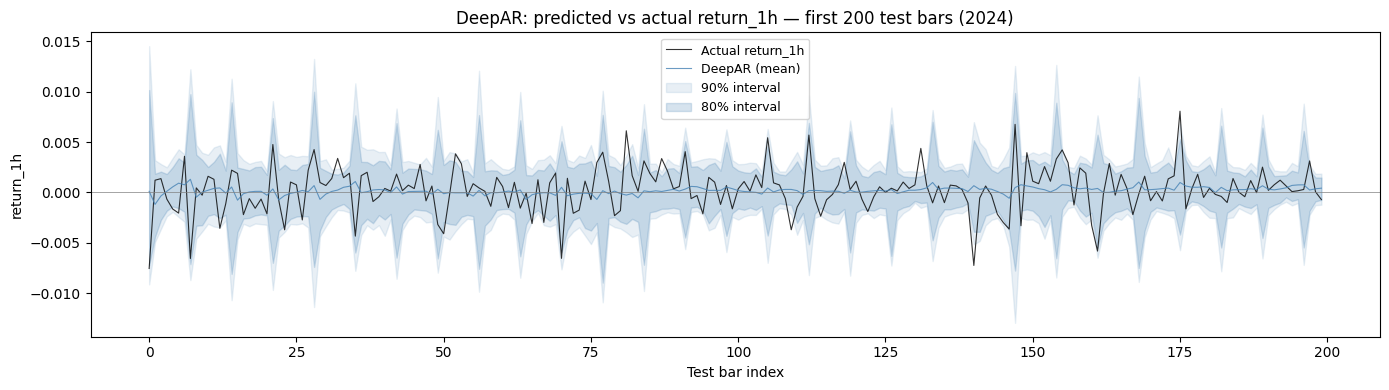

In [8]:
n = 200
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), y_true[:n], label='Actual return_1h', alpha=0.8, linewidth=0.8, color='black')
ax.plot(range(n), y_pred[:n], label='DeepAR (mean)',    alpha=0.8, linewidth=0.8, color='steelblue')
ax.fill_between(range(n), lo_90[:n], hi_90[:n], alpha=0.12, color='steelblue', label='90% interval')
ax.fill_between(range(n), lo_80[:n], hi_80[:n], alpha=0.22, color='steelblue', label='80% interval')
ax.axhline(0, color='gray', linewidth=0.5)
ax.legend(fontsize=9)
ax.set_title('DeepAR: predicted vs actual return_1h — first 200 test bars (2024)')
ax.set_xlabel('Test bar index')
ax.set_ylabel('return_1h')
plt.tight_layout()
plt.show()

In [9]:
test_raw = pd.read_parquet('../data/splits/test.parquet').reset_index(drop=True)

preds_df = pd.DataFrame({
    'ds':       cv_test['ds'].values,
    'datetime': test_raw['datetime'].values[:len(cv_test)],
    'y':        y_true,
    'pred':     y_pred,
    'lo_80':    lo_80,
    'hi_80':    hi_80,
    'lo_90':    lo_90,
    'hi_90':    hi_90,
    'model':    'DeepAR',
})
preds_df.to_parquet('../data/predictions/deepar_preds.parquet', index=False)
print(f"Saved {len(preds_df):,} rows → data/predictions/deepar_preds.parquet")
print(preds_df.head(3))

Saved 2,469 rows → data/predictions/deepar_preds.parquet
      ds            datetime         y      pred     lo_80     hi_80  \
0  22772 2024-01-02 09:30:00 -0.007552  0.000107 -0.007244  0.010153   
1  22773 2024-01-02 10:30:00  0.001208 -0.001191 -0.004397  0.001848   
2  22774 2024-01-02 11:30:00  0.001366 -0.000355 -0.002725  0.002058   

      lo_90     hi_90   model  
0 -0.009129  0.014511  DeepAR  
1 -0.004921  0.003193  DeepAR  
2 -0.003633  0.002811  DeepAR  
